# Experiment 2: Borderline-SMOTE + SVM

## 1. Scientific Motivation
Photometric observations of quasars and stars produce heavily overlapping colour distributions. Standard oversampling (SMOTE) generates synthetic minority samples uniformly across the minority region. Borderline-SMOTE specifically targets the **minority samples closest to the decision boundary**, generating new samples in the most ambiguous photometric regions where the classifier struggles most.

Combined with a **Support Vector Machine** (SVM), which directly optimises a separating hyperplane margin, this pipeline investigates whether **boundary-aware synthetic enrichment + margin maximisation** produces more reliable quasar recovery.


## 2. Research Question
Can boundary-focused oversampling combined with margin optimisation improve reliable quasar identification in overlapping photometric regions?


## 3. Pipeline Philosophy
- **Borderline-SMOTE** generates synthetic minority samples near the most ambiguous boundary regions
- **SVM (RBF Kernel)** constructs a maximum-margin hyperplane, well-suited for overlap-heavy classification
- Together: boundary enrichment + margin maximisation


## 4. Setup & Data Loading


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE

RANDOM_STATE = 42
TEST_SIZE = 0.2

data_path = '../../data/raw/Skyserver_Cross.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded. Full Shape: {df.shape}')


Dataset loaded. Full Shape: (500000, 7)


## 5. Stratified Cap (50k rows)
SVM training scales quadratically with dataset size. To keep training time manageable, we sample the data down to 50,000 rows while preserving the class distribution.


In [2]:
MAX_ROWS = 50_000
if len(df) > MAX_ROWS:
    df = df.groupby('class', group_keys=False).apply(
        lambda x: x.sample(n=int(MAX_ROWS * len(x) / len(df)), random_state=RANDOM_STATE)
    ).reset_index(drop=True)
    print(f'Dataset capped to {len(df):,} rows.')


Dataset capped to 49,999 rows.


C:\Users\KALIDASAN\AppData\Local\Temp\ipykernel_28188\1221330599.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('class', group_keys=False).apply(


## 6. Binary Reformulation & Feature Engineering
Using the 5 baseline features, 4 standard color indices, and 1 geometric color distance feature tailored for the RBF kernel.


In [3]:
df['target'] = (df['class'] == 'QSO').astype(int)

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']
df['color_distance'] = np.sqrt(df['u_g']**2 + df['g_r']**2 + df['r_i']**2 + df['i_z']**2)

feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'color_distance']
X = df[feature_cols]
y = df['target']


## 7. Train-Test Split & Scaling


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Borderline-SMOTE Oversampling
Enrich the boundary with synthetic minority (Quasar) samples.


In [5]:
print('Before Borderline-SMOTE:', np.bincount(y_train))
bsmote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
X_train_res, y_train_res = bsmote.fit_resample(X_train_scaled, y_train)
print('After Borderline-SMOTE:', np.bincount(y_train_res))


Before Borderline-SMOTE: [33968  6031]
After Borderline-SMOTE: [33968 33968]


## 9. Model Training


In [6]:
model = SVC(C=1.0, kernel='rbf', random_state=RANDOM_STATE)
model.fit(X_train_res, y_train_res)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 10. Evaluation


              precision    recall  f1-score   support

  Non-Quasar       0.99      0.88      0.93      8492
      Quasar       0.58      0.94      0.71      1508

    accuracy                           0.89     10000
   macro avg       0.78      0.91      0.82     10000
weighted avg       0.93      0.89      0.90     10000



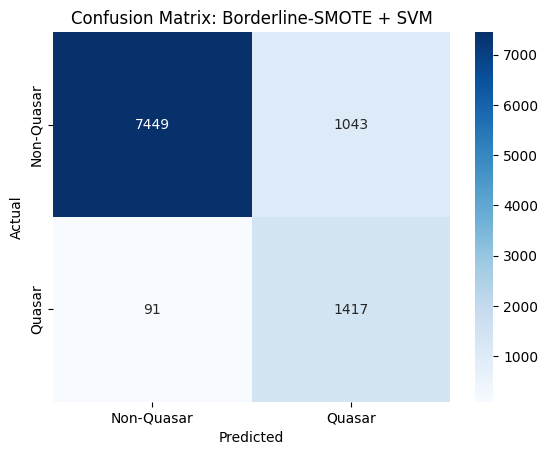

In [7]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Non-Quasar', 'Quasar']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Quasar', 'Quasar'], yticklabels=['Non-Quasar', 'Quasar'])
plt.title('Confusion Matrix: Borderline-SMOTE + SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 11. Save Model for UI Deployment
Save the trained SVM model for Streamlit inference.


In [8]:
os.makedirs('../../models', exist_ok=True)
joblib.dump(model, '../../models/member2_svm.pkl')
joblib.dump(scaler, '../../models/scaler_m2.pkl')
print('Model and Scaler saved to models/ directory.')


Model and Scaler saved to models/ directory.
